In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('toxic_comments_dataset.csv')

# 2. Display the first 10 records
print("--- First 10 Records ---")
display(df.head(10))

# 3. Display the last 8 records
print("\n--- Last 8 Records ---")
display(df.tail(8))

# 4. Check the dataset shape (Rows and Columns)
print("\n--- Dataset Shape ---")
print(df.shape)

# 5. Display column names and data types
print("\n--- Column Names and Data Types ---")
print(df.info())

# 6. Display statistical summary
print("\n--- Statistical Summary ---")
display(df.describe())

--- First 10 Records ---


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
0,COM000001,The message targets a group unfairly and viola...,Identity_Attack,0,1,0,0,1,0.818,66,10,Community Chat,Sports,High,English
1,COM000002,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.069,58,9,News Comments,Entertainment,High,English
2,COM000003,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.622,44,7,Social Media,Politics,Low,English
3,COM000004,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.010,61,9,Social Media,Entertainment,Low,English
4,COM000005,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.140,52,8,Blog,Sports,Low,English
5,COM000006,That response is aggressive and not helpful.,Toxic,0,1,0,0,0,0.729,44,7,Social Media,Technology,Low,English
6,COM000007,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.193,52,8,Blog,Entertainment,Low,English
7,COM000008,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.183,61,9,Forum,Gaming,Low,English
8,COM000009,This article provides useful information and c...,Clean,1,0,0,0,0,0.142,60,8,Social Media,Education,Medium,English
9,COM000010,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.153,61,9,Forum,Entertainment,Low,English



--- Last 8 Records ---


,Comment_ID,Comment_Text,Toxicity_Label,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count,Platform,Topic,Moderation_Priority,Language
29992,COM029993,Your message is unnecessarily hostile and offe...,Toxic,0,1,0,0,0,0.520,52,7,Forum,Gaming,Medium,English
29993,COM029994,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.195,61,9,News Comments,Sports,Medium,English
29994,COM029995,Thank you for sharing this perspective with th...,Clean,1,0,0,0,0,0.174,58,9,Community Chat,Gaming,Low,English
29995,COM029996,This article provides useful information and c...,Clean,1,0,0,0,0,0.013,60,8,Community Chat,Sports,Medium,English
29996,COM029997,I respectfully disagree but I understand your ...,Clean,1,0,0,0,0,0.050,52,8,Blog,Politics,Medium,English
29997,COM029998,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.078,61,9,Forum,Sports,Low,English
29998,COM029999,This article provides useful information and c...,Clean,1,0,0,0,0,0.003,60,8,Social Media,Sports,Medium,English
29999,COM030000,I appreciate your explanation and the discussi...,Clean,1,0,0,0,0,0.082,61,9,Community Chat,Education,High,English



--- Dataset Shape ---
(30000, 15)

--- Column Names and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Comment_ID           30000 non-null  str    
 1   Comment_Text         30000 non-null  str    
 2   Toxicity_Label       30000 non-null  str    
 3   Clean                30000 non-null  int64  
 4   Toxic                30000 non-null  int64  
 5   Severe_Toxic         30000 non-null  int64  
 6   Threat               30000 non-null  int64  
 7   Identity_Attack      30000 non-null  int64  
 8   Toxicity_Score       30000 non-null  float64
 9   Comment_Length       30000 non-null  int64  
 10  Word_Count           30000 non-null  int64  
 11  Platform             30000 non-null  str    
 12  Topic                30000 non-null  str    
 13  Moderation_Priority  30000 non-null  str    
 14  Language             3000

,Clean,Toxic,Severe_Toxic,Threat,Identity_Attack,Toxicity_Score,Comment_Length,Word_Count
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.619300,0.380700,0.060033,0.048633,0.048933,0.324542,56.357633,8.340633
std,0.485567,0.485567,0.237553,0.215104,0.215732,0.302914,6.962596,0.972094
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,39.000000,6.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.079000,52.000000,8.000000
50%,1.000000,0.000000,0.000000,0.000000,0.000000,0.161000,58.000000,8.000000
75%,1.000000,1.000000,0.000000,0.000000,0.000000,0.624000,61.000000,9.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,0.950000,71.000000,11.000000


--- Toxicity Label Distribution ---
Toxicity_Label
Clean              18579
Toxic               6693
Severe_Toxic        1801
Identity_Attack     1468
Threat              1459
Name: count, dtype: int64


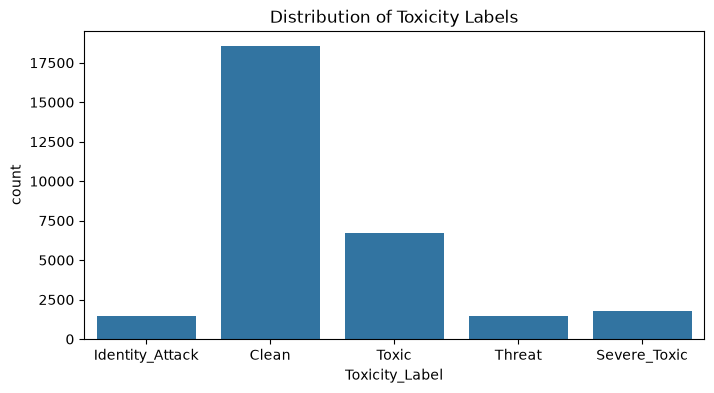


--- Cleaned Text Samples ---
0    the message targets a group unfairly and viola...
1    thank you for sharing this perspective with th...
2          that response is aggressive and not helpful
3    i appreciate your explanation and the discussi...
4    i respectfully disagree but i understand your ...
Name: Comment_Text, dtype: str


In [5]:
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the correct column names based on your output
text_col = 'Comment_Text'
target_col = 'Toxicity_Label'

# 2. Text Cleaning Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text) # Remove tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text) # Remove punctuation
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.strip()
    text = re.sub(r'\s+', ' ', text) # Remove extra spaces
    return text

# Apply cleaning
df[text_col] = df[text_col].apply(clean_text)

# 3. Target Analysis (Label Distribution)
print("--- Toxicity Label Distribution ---")
label_counts = df[target_col].value_counts()
print(label_counts)

# 4. Visualize the distribution (Small Plot)
plt.figure(figsize=(8,4))
sns.countplot(x=target_col, data=df)
plt.title('Distribution of Toxicity Labels')
plt.show()

print("\n--- Cleaned Text Samples ---")
print(df[text_col].head())

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Separate Input (Text) and Target (Label)
X = df['Comment_Text']
y = df['Toxicity_Label']

# 2. Encode Labels (Convert 'Toxic', 'Clean' etc. into 0, 1, 2...)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)
print(f"Classes found: {label_encoder.classes_}")

# 3. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Initialize Tokenizer
# We only "fit" (learn the words) on the Training data
max_words = 10000  # Only keep the top 10,000 most frequent words
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 5. Convert text to sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 6. Padding: Make every comment the same length
max_length = 100 # We will make every comment 100 "words" long
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

print("\n--- Tokenization Results ---")
print(f"Original Text: {X_train.iloc[0]}")
print(f"Numerical Sequence: {X_train_seq[0][:10]}... (truncated)")
print(f"Padded Shape: {X_train_padded.shape}")

ModuleNotFoundError: No module named 'tensorflow'